🚀 INITIALIZING CJP SENTINEL V8 ADVANCED LOCAL AUDIT...


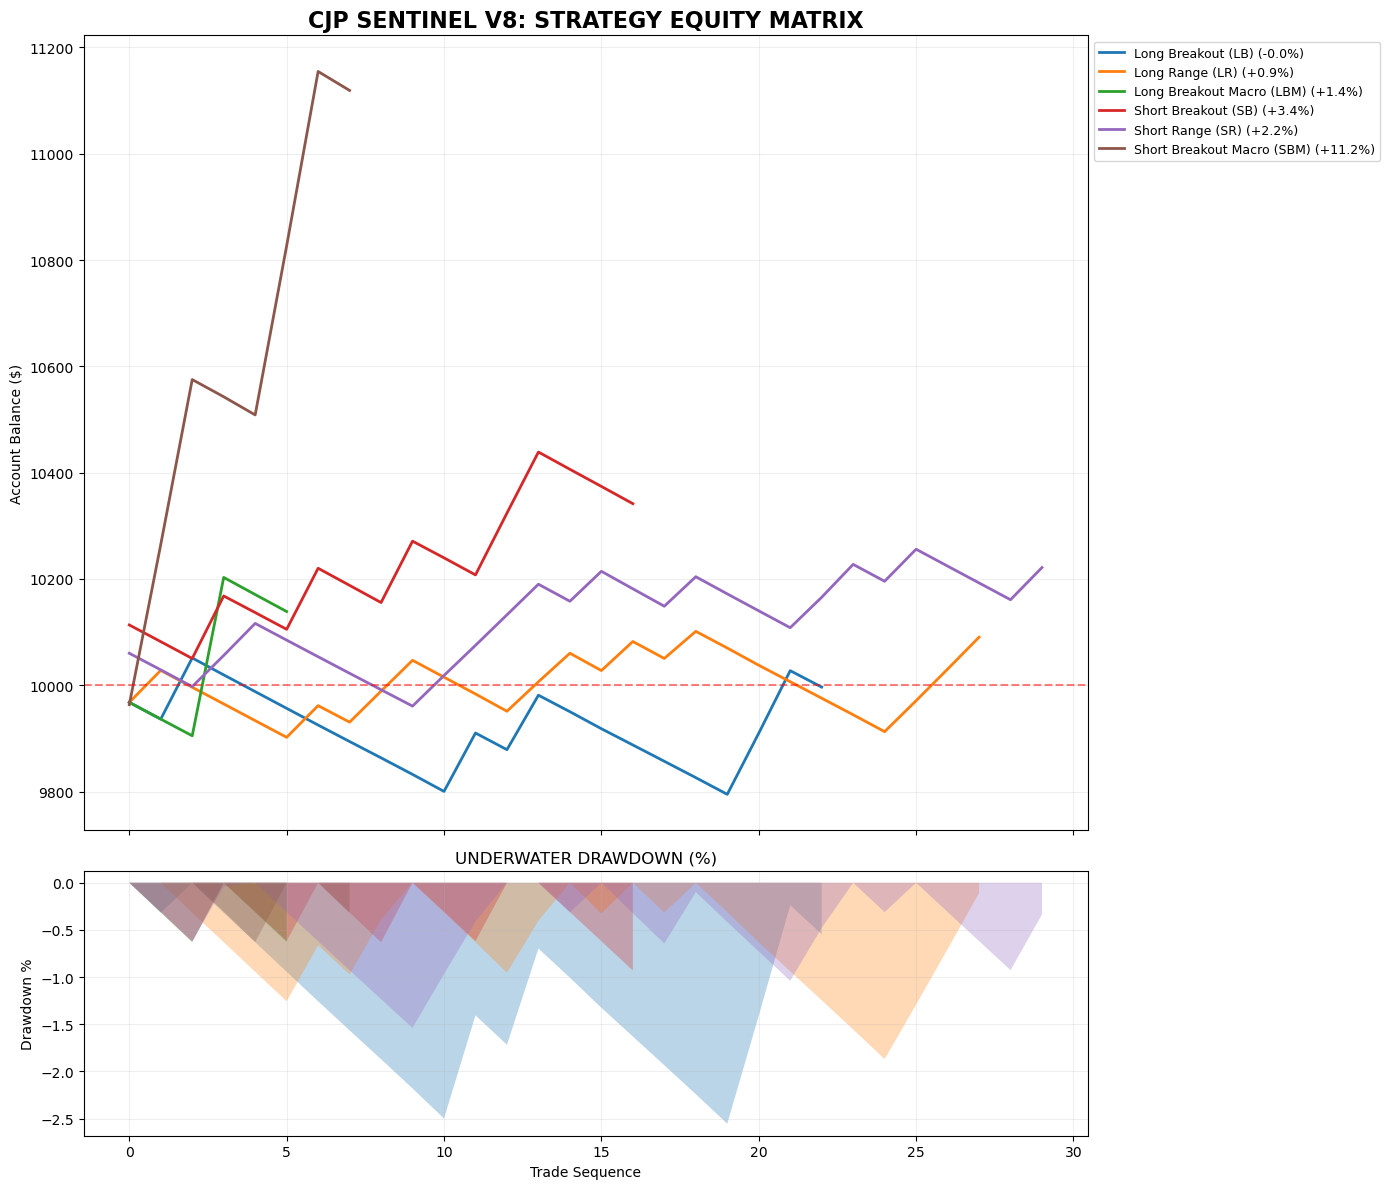


✅ AUDIT COMPLETE
📊 Chart saved to: C:\Users\ajimo\Strategy Backtesting\cjp_sentinel_v8_advanced.png
📑 Metrics saved to: C:\Users\ajimo\Strategy Backtesting\cjp_sentinel_v8_audit.csv


,Strategy,Final Balance ($),Perf (%),Highest Bal (%),Max Drawdown,Risk Reward,Win Rate
3,Short Breakout (SB),"10,341.65",3.42%,4.39%,-0.93%,1:3.62,35.3%
4,Short Range (SR),"10,221.52",2.22%,2.56%,-1.54%,1:1.85,43.3%
5,Short Breakout Macro (SBM),"11,119.14",11.19%,11.55%,-0.63%,1:9.54,50.0%
2,Long Breakout Macro (LBM),"10,138.72",1.39%,2.03%,-0.63%,1:9.36,16.7%
1,Long Range (LR),"10,090.42",0.90%,1.01%,-1.87%,1:1.80,39.3%
0,Long Breakout (LB),"9,996.54",-0.03%,0.51%,-2.55%,1:3.58,21.7%


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. QUADRANT CONFIGURATION
sentinel_files = {
    "Long Breakout (LB)": "cjpsentinellb.csv",
    "Long Range (LR)": "cjpsentinellr.csv",
    "Long Breakout Macro (LBM)": "cjpsentinellbm.csv",
    "Short Breakout (SB)": "cjpsentinelsb.csv",
    "Short Range (SR)": "cjpsentinelsr.csv",
    "Short Breakout Macro (SBM)": "cjpsentinelsbm.csv",
}

def run_advanced_audit_local():
    summary = []
    initial_bal = 10000
    
    # Create a 2-row subplot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    
    print("🚀 INITIALIZING CJP SENTINEL V8 ADVANCED LOCAL AUDIT...")
    
    for label, file in sentinel_files.items():
        if not os.path.exists(file):
            print(f"⚠️ Missing file: {file}")
            continue
            
        try:
            df = pd.read_csv(file)
            bal_col = 'bal' if 'bal' in df.columns else 'bal_after'
            pnl_col = 'pnl' if 'pnl' in df.columns else 'pnl_net'
            
            # --- CALCULATE METRICS ---
            equity = df[bal_col]
            net_pnl = equity.iloc[-1] - initial_bal
            perf_pct = (net_pnl / initial_bal) * 100
            
            rolling_max = equity.cummax()
            drawdown = ((equity - rolling_max) / rolling_max) * 100
            mdd = drawdown.min()
            
            highest_bal_pct = ((equity.max() - initial_bal) / initial_bal) * 100
            
            wins = df[df[pnl_col] > 0][pnl_col]
            losses = df[df[pnl_col] < 0][pnl_col]
            rr_ratio = (wins.mean() / abs(losses.mean())) if not losses.empty else np.inf
            
            summary.append({
                "Strategy": label,
                "Final Balance ($)": f"{equity.iloc[-1]:,.2f}",
                "Perf (%)": f"{perf_pct:.2f}%",
                "Highest Bal (%)": f"{highest_bal_pct:.2f}%",
                "Max Drawdown": f"{mdd:.2f}%",
                "Risk Reward": f"1:{rr_ratio:.2f}",
                "Win Rate": f"{(len(wins)/len(df)*100):.1f}%"
            })
            
            # --- PLOTTING ---
            ax1.plot(equity.values, label=f"{label} ({perf_pct:+.1f}%)", linewidth=2)
            ax2.fill_between(range(len(drawdown)), drawdown, 0, alpha=0.3)
            
        except Exception as e:
            print(f"⚠️ Error processing {label}: {e}")

    # Chart Styling
    ax1.set_title("CJP SENTINEL V8: STRATEGY EQUITY MATRIX", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Account Balance ($)")
    ax1.axhline(y=initial_bal, color='red', linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
    ax1.grid(alpha=0.2)

    ax2.set_title("UNDERWATER DRAWDOWN (%)", fontsize=12)
    ax2.set_ylabel("Drawdown %")
    ax2.set_xlabel("Trade Sequence")
    ax2.grid(alpha=0.2)
    
    plt.tight_layout()
    
    # Save Files Locally
    chart_out = "cjp_sentinel_v8_advanced.png"
    csv_out = "cjp_sentinel_v8_audit.csv"
    
    plt.savefig(chart_out, dpi=300)
    plt.show()

    # Table Export
    perf_df = pd.DataFrame(summary).sort_values(by="Perf (%)", ascending=False)
    perf_df.to_csv(csv_out, index=False)
    
    print("\n✅ AUDIT COMPLETE")
    print(f"📊 Chart saved to: {os.path.abspath(chart_out)}")
    print(f"📑 Metrics saved to: {os.path.abspath(csv_out)}")
    
    return perf_df

# Execute
df_results = run_advanced_audit_local()
df_results

🚀 GENERATING OMEGA AUDIT (HEDGE FUND STANDARD)...


,Perf (%),Max DD (%),Sharpe,Sortino,Calmar,Recov. Factor,Profit Factor,Win Rate
Long Breakout (LB),-0.03%,-2.55%,-0.01,-1.44,0.01,-0.01,0.99,21.7%
Long Range (LR),0.90%,-1.87%,0.39,32.33,0.48,0.48,1.17,39.3%
Long Macro (LBM),1.39%,-0.63%,0.42,140.71,2.2,2.16,1.87,16.7%
Short Breakout (SB),3.42%,-0.93%,1.14,179.68,3.67,3.52,1.97,35.3%
Short Range (SR),2.22%,-1.54%,0.89,69.62,1.44,1.42,1.41,43.3%
Short Macro (SBM),11.19%,-0.63%,2.14,310.24,17.79,16.82,9.54,50.0%
TOTAL PORTFOLIO,19.15%,-2.06%,2.2,270.93,9.3,8.33,1.84,35.7%



📥 DOWNLOAD INSTITUTIONAL ASSETS:


C:\Users\ajimo\Strategy Backtesting\cjp_omega_hedgefund_report.csv

C:\Users\ajimo\Strategy Backtesting\cjp_omega_audit_v8.png

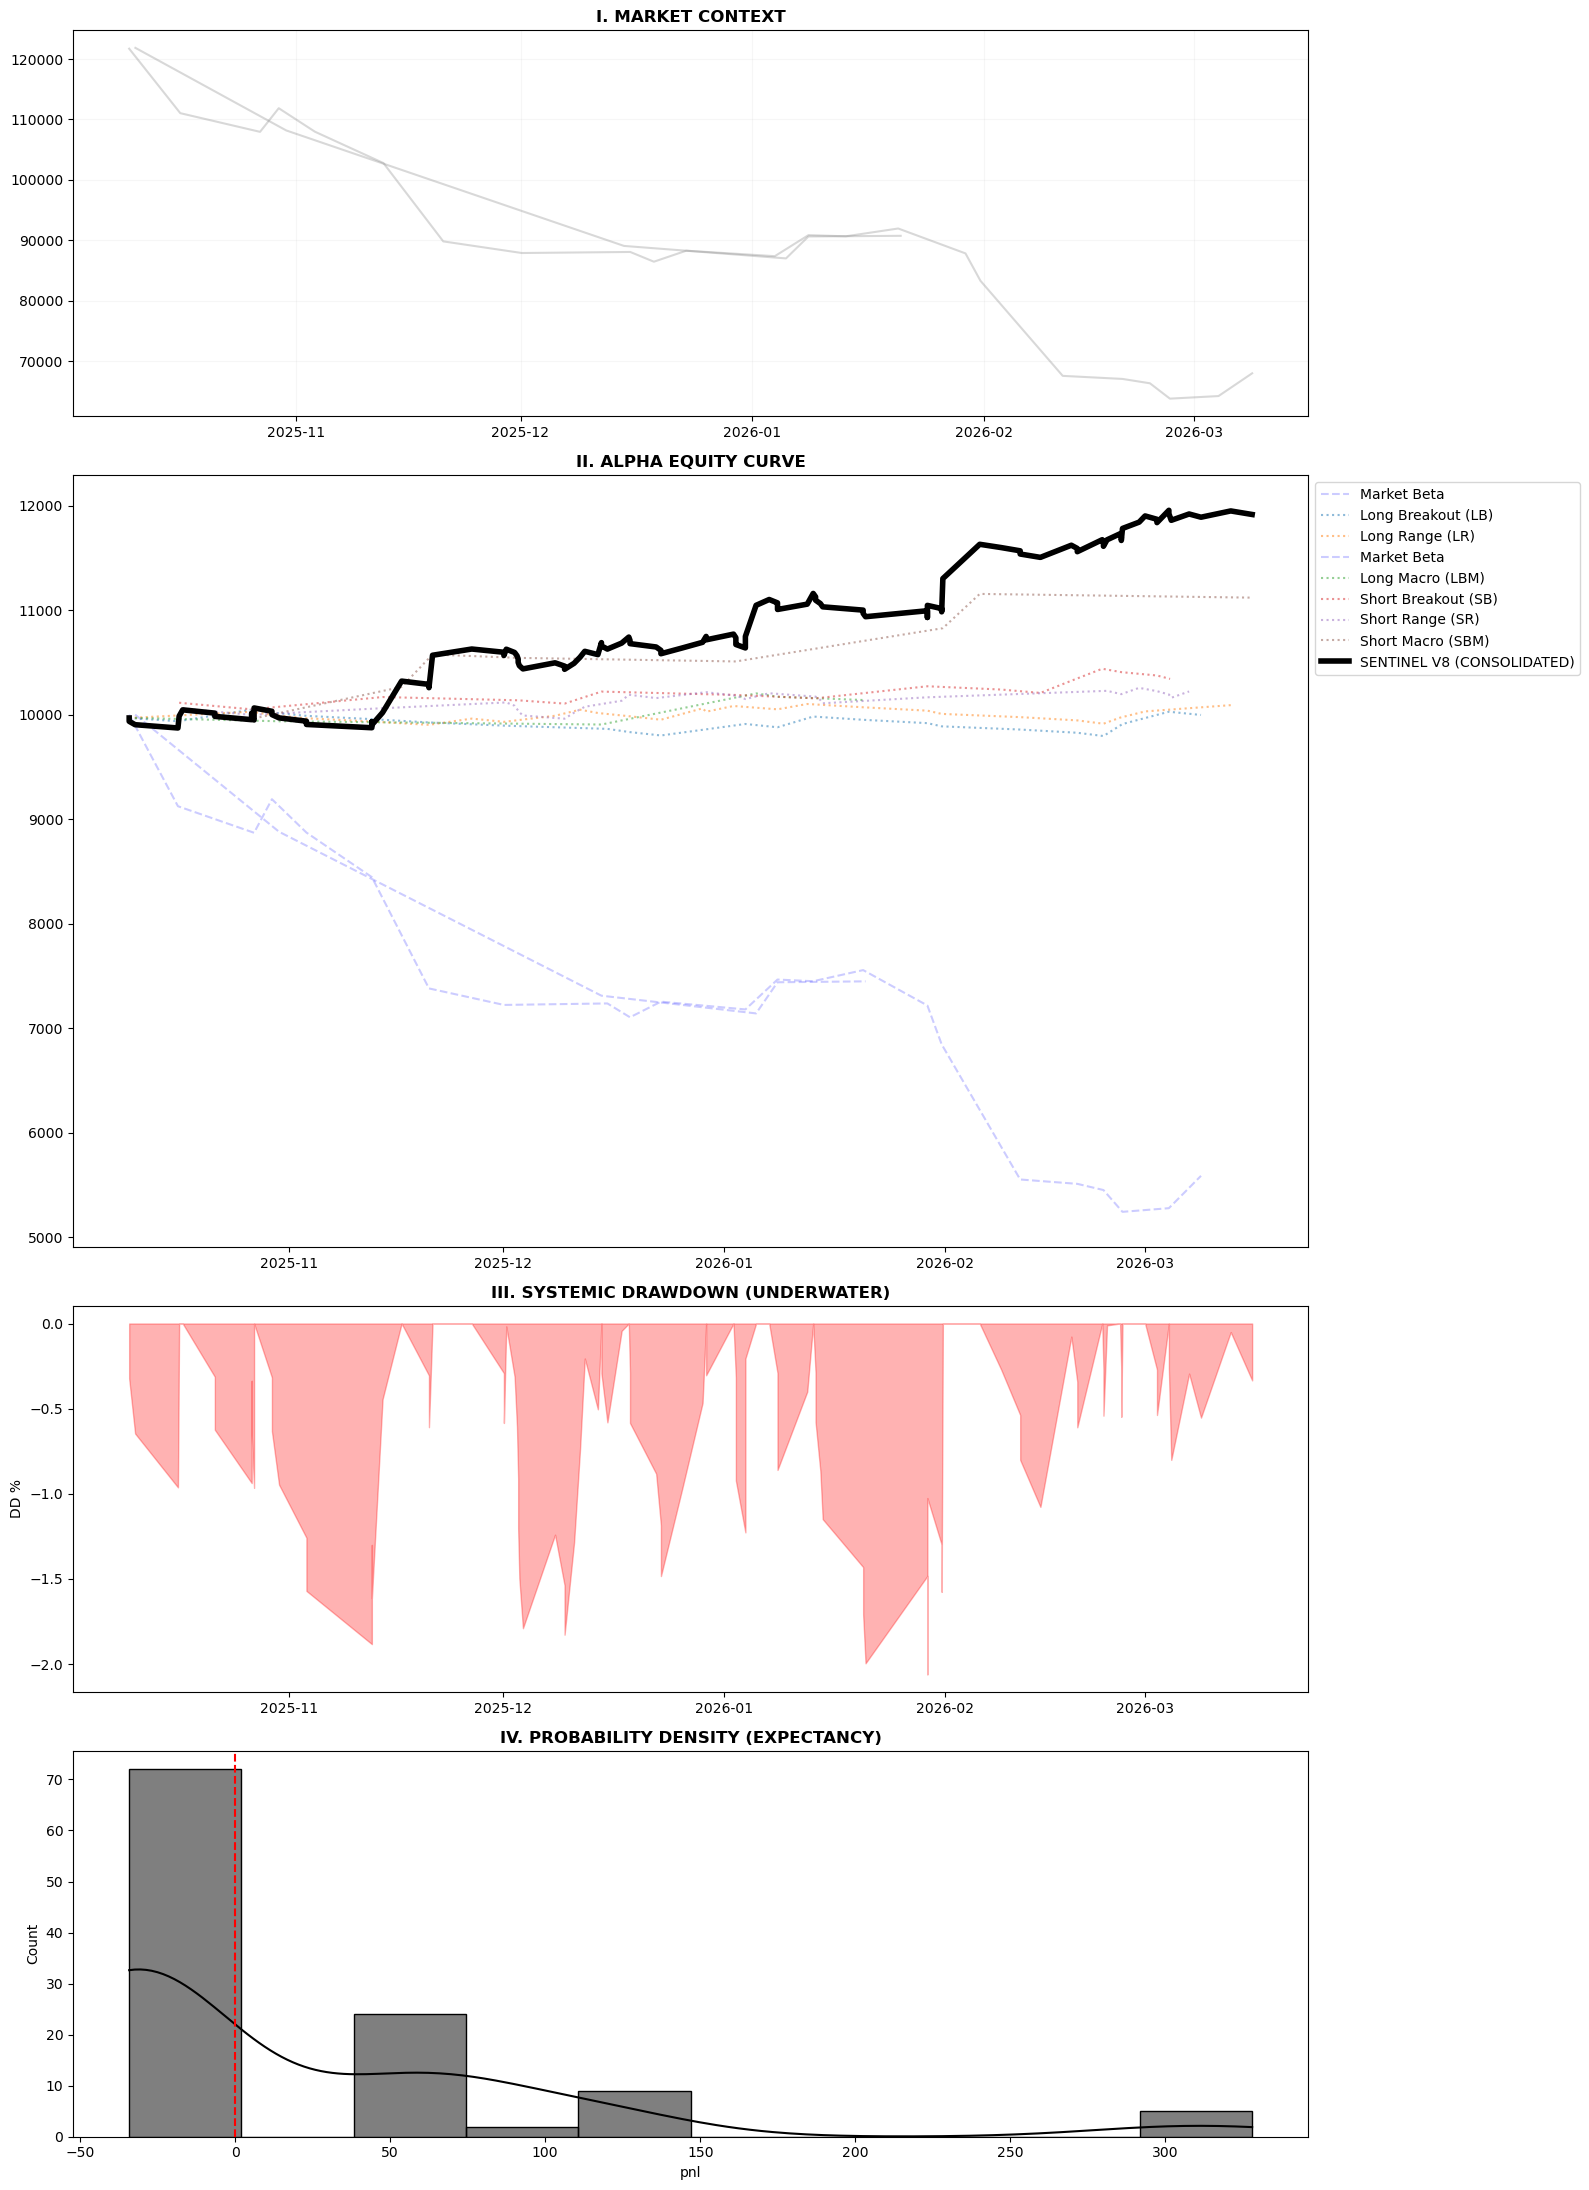

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import FileLink, display

# 1. QUADRANT CONFIGURATION (Standard 6-Matrix)
files = {
    "Long Breakout (LB)": "cjpsentinellb.csv",
    "Long Range (LR)": "cjpsentinellr.csv",
    "Long Macro (LBM)": "cjpsentinellbm.csv",
    "Short Breakout (SB)": "cjpsentinelsb.csv",
    "Short Range (SR)": "cjpsentinelsr.csv",
    "Short Macro (SBM)": "cjpsentinelsbm.csv",
}

def run_omega_audit_v8():
    all_trade_logs = []
    metrics = {}
    initial_balance = 10000
    
    # 4-Pane Master Plot: Price, Equity, Drawdown, PnL Distribution
    fig = plt.figure(figsize=(16, 22))
    gs = fig.add_gridspec(4, 1, height_ratios=[1, 2, 1, 1])
    ax1 = fig.add_subplot(gs[0]) # Market Context
    ax2 = fig.add_subplot(gs[1]) # Equity Curves
    ax3 = fig.add_subplot(gs[2]) # Underwater Drawdown
    ax4 = fig.add_subplot(gs[3]) # Trade Distribution
    
    print("🚀 GENERATING OMEGA AUDIT (HEDGE FUND STANDARD)...")

    for label, path in files.items():
        if not os.path.exists(path): continue
        
        try:
            df = pd.read_csv(path)
            df['ts'] = pd.to_datetime(df['ts'])
            bal_col = 'bal' if 'bal' in df.columns else 'bal_after'
            pnl_col = 'pnl' if 'pnl' in df.columns else 'pnl_net'
            
            equity = df[bal_col]
            pnls = df[pnl_col]
            
            # --- HEDGE FUND METRICS ---
            net_pnl = equity.iloc[-1] - initial_balance
            perf_pct = (net_pnl / initial_balance) * 100
            
            # Drawdown & Recovery
            rolling_max = equity.cummax()
            dd_series = ((equity - rolling_max) / rolling_max) * 100
            mdd_pct = dd_series.min()
            mdd_usd = (rolling_max - equity).max()
            recovery_factor = net_pnl / mdd_usd if mdd_usd > 0 else np.inf
            
            # Risk-Adjusted Ratios
            vol = pnls.std()
            sharpe = (pnls.mean() / vol * np.sqrt(len(df))) if vol != 0 else 0
            
            downside_pnls = pnls[pnls < 0]
            sortino = (pnls.mean() / downside_pnls.std() * np.sqrt(len(df))) if not downside_pnls.empty else np.inf
            
            # Calmar Ratio (Annualized Return / Max DD)
            calmar = abs(perf_pct / mdd_pct) if mdd_pct != 0 else np.inf

            metrics[label] = {
                "Perf (%)": f"{perf_pct:.2f}%",
                "Max DD (%)": f"{mdd_pct:.2f}%",
                "Sharpe": round(sharpe, 2),
                "Sortino": round(sortino, 2),
                "Calmar": round(calmar, 2),
                "Recov. Factor": round(recovery_factor, 2),
                "Profit Factor": round(pnls[pnls>0].sum() / abs(pnls[pnls<0].sum()), 2),
                "Win Rate": f"{(len(pnls[pnls>0])/len(pnls)*100):.1f}%"
            }
            
            # Market Context Logic
            if "LB" in label and 'entry' in df.columns:
                ax1.plot(df['ts'], df['entry'], color='gray', alpha=0.3, label="Market Price")
                benchmark = (df['entry'] / df['entry'].iloc[0]) * initial_balance
                ax2.plot(df['ts'], benchmark, color='blue', alpha=0.2, linestyle='--', label="Market Beta")

            ax2.plot(df['ts'], equity, alpha=0.5, linestyle=':', label=label)
            all_trade_logs.append(df[['ts', pnl_col]].rename(columns={pnl_col: 'pnl'}))

        except Exception as e:
            print(f"⚠️ Error in {label}: {e}")

    # 2. TOTAL SYSTEM PERFORMANCE
    portfolio = pd.concat(all_trade_logs).sort_values('ts')
    portfolio['total_bal'] = initial_balance + portfolio['pnl'].cumsum()
    p_eq = portfolio['total_bal']
    p_pnls = portfolio['pnl']
    
    p_mdd_series = ((p_eq - p_eq.cummax()) / p_eq.cummax()) * 100
    
    metrics["TOTAL PORTFOLIO"] = {
        "Perf (%)": f"{((p_eq.iloc[-1]-initial_balance)/initial_balance*100):.2f}%",
        "Max DD (%)": f"{p_mdd_series.min():.2f}%",
        "Sharpe": round(p_pnls.mean()/p_pnls.std()*np.sqrt(len(portfolio)), 2),
        "Sortino": round(p_pnls.mean()/p_pnls[p_pnls<0].std()*np.sqrt(len(portfolio)), 2),
        "Calmar": round(abs(((p_eq.iloc[-1]-initial_balance)/initial_balance*100) / p_mdd_series.min()), 2),
        "Recov. Factor": round((p_eq.iloc[-1]-initial_balance) / (p_eq.cummax()-p_eq).max(), 2),
        "Profit Factor": round(p_pnls[p_pnls>0].sum() / abs(p_pnls[p_pnls<0].sum()), 2),
        "Win Rate": f"{(len(p_pnls[p_pnls>0])/len(p_pnls)*100):.1f}%"
    }

    # 3. VISUALIZATION
    ax1.set_title("I. MARKET CONTEXT", fontweight='bold'); ax1.grid(alpha=0.1)
    
    ax2.plot(portfolio['ts'], p_eq, color='black', linewidth=4, label="SENTINEL V8 (CONSOLIDATED)")
    ax2.set_title("II. ALPHA EQUITY CURVE", fontweight='bold'); ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    ax3.fill_between(portfolio['ts'], p_mdd_series, 0, color='red', alpha=0.3)
    ax3.set_title("III. SYSTEMIC DRAWDOWN (UNDERWATER)", fontweight='bold'); ax3.set_ylabel("DD %")
    
    sns.histplot(p_pnls, kde=True, ax=ax4, color='black')
    ax4.axvline(0, color='red', linestyle='--')
    ax4.set_title("IV. PROBABILITY DENSITY (EXPECTANCY)", fontweight='bold')

    plt.tight_layout()
    plt.savefig("cjp_omega_audit_v8.png", dpi=300)
    
    # 4. EXPORT
    perf_table = pd.DataFrame(metrics).T
    perf_table.to_csv("cjp_omega_hedgefund_report.csv")
    display(perf_table)
    
    print("\n📥 DOWNLOAD INSTITUTIONAL ASSETS:")
    display(FileLink('cjp_omega_hedgefund_report.csv'))
    display(FileLink('cjp_omega_audit_v8.png'))

run_omega_audit_v8()

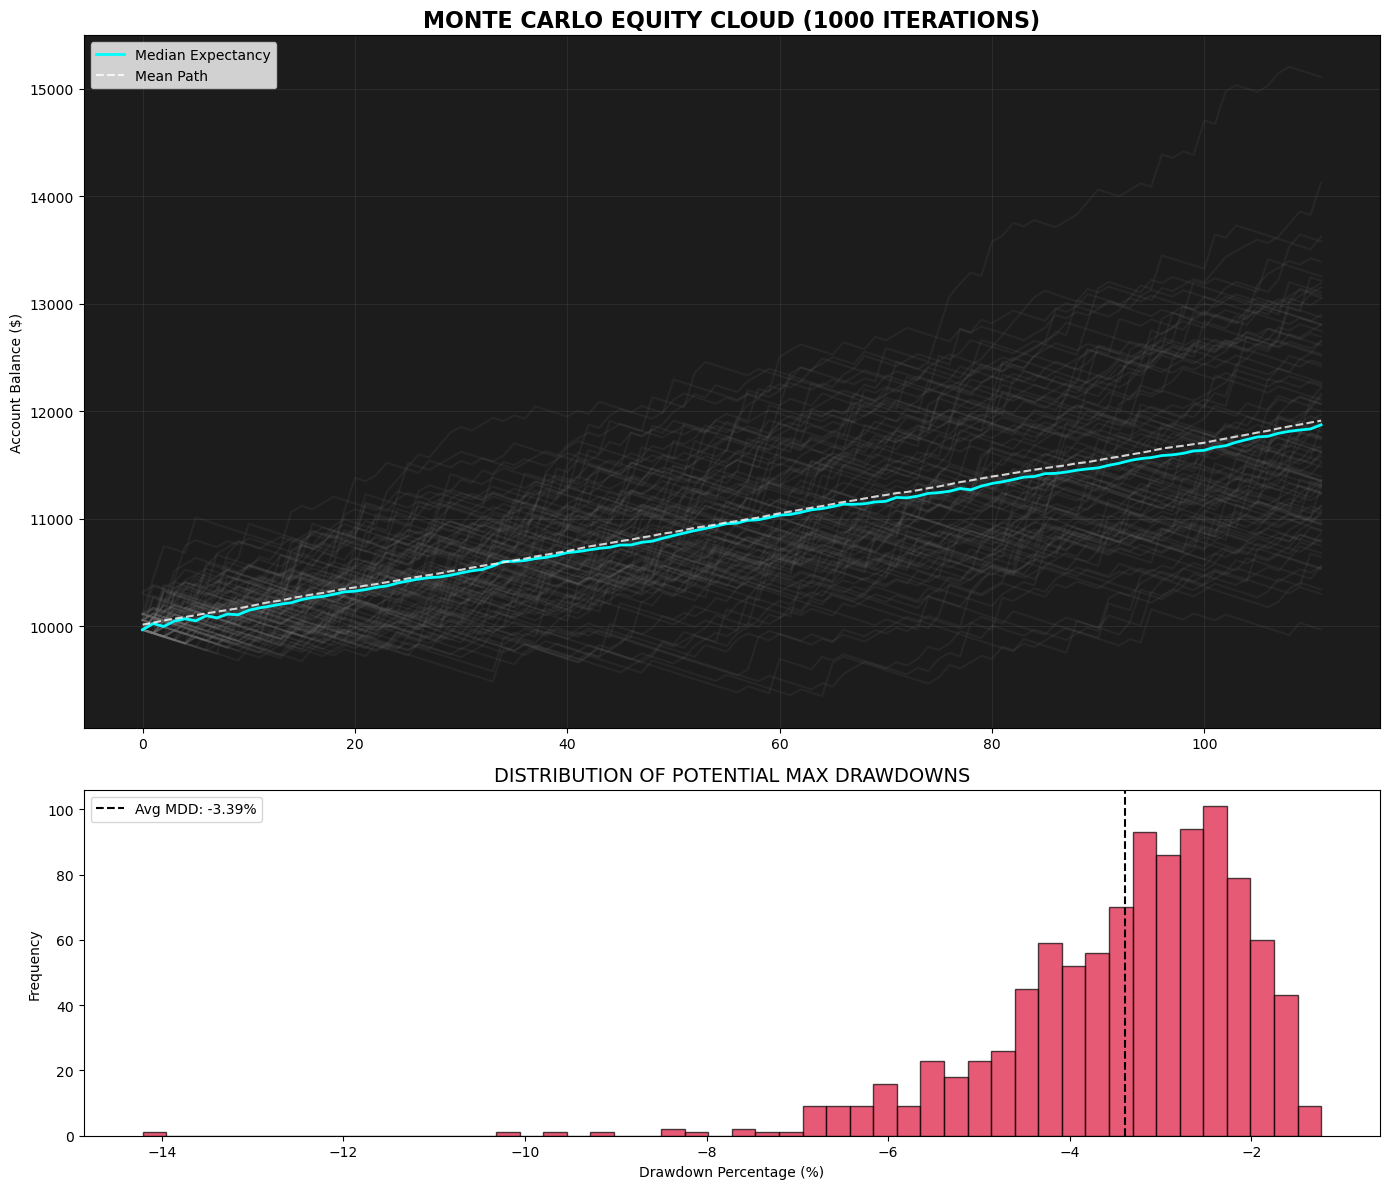

,Value
Simulations,1000
Avg Final Balance,"$11,913.57"
95% Confidence Floor,"$10,532.79"
Risk of Ruin (%),0.70%
Worst Case MDD,-14.21%
Probable MDD,-3.39%



📥 DOWNLOAD STRESS TEST RESULTS:


C:\Users\ajimo\Strategy Backtesting\cjp_monte_carlo_results.csv

C:\Users\ajimo\Strategy Backtesting\cjp_monte_carlo_audit.png

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import FileLink, display

# 1. CONFIGURATION
files = [
    "cjpsentinellb.csv", "cjpsentinellr.csv", "cjpsentinellbm.csv",
    "cjpsentinelsb.csv", "cjpsentinelsr.csv", "cjpsentinelsbm.csv"
]

def run_monte_carlo_audit(simulations=1000, starting_capital=10000):
    all_pnls = []
    
    # Load all trades into one master list
    for f in files:
        if os.path.exists(f):
            df = pd.read_csv(f)
            p_col = 'pnl' if 'pnl' in df.columns else 'pnl_net'
            all_pnls.extend(df[p_col].tolist())
    
    if not all_pnls:
        print("❌ No trade data found for simulation.")
        return

    trade_array = np.array(all_pnls)
    n_trades = len(trade_array)
    
    # 2. EXECUTE SIMULATIONS
    # We shuffle the trades 1000 times to create 1000 alternative 'realities'
    sim_results = np.zeros((simulations, n_trades))
    final_balances = []
    max_drawdowns = []

    for i in range(simulations):
        # Randomly sample trades with replacement (Bootstrap method)
        sim_trades = np.random.choice(trade_array, size=n_trades, replace=True)
        equity_curve = starting_capital + np.cumsum(sim_trades)
        sim_results[i, :] = equity_curve
        
        # Calculate Max DD for this specific simulation
        roll_max = np.maximum.accumulate(equity_curve)
        dd = (equity_curve - roll_max) / roll_max
        max_drawdowns.append(np.min(dd) * 100)
        final_balances.append(equity_curve[-1])

    # 3. VISUALIZATION
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [2, 1]})
    
    # Pane 1: Equity Cloud
    for i in range(min(simulations, 100)): # Plot 100 sample paths for clarity
        ax1.plot(sim_results[i, :], color='gray', alpha=0.1)
    
    # Highlight the Median Path
    median_path = np.median(sim_results, axis=0)
    ax1.plot(median_path, color='cyan', linewidth=2, label='Median Expectancy')
    ax1.plot(sim_results.mean(axis=0), color='white', linestyle='--', label='Mean Path', alpha=0.8)
    
    ax1.set_title(f"MONTE CARLO EQUITY CLOUD ({simulations} ITERATIONS)", fontsize=16, fontweight='bold')
    ax1.set_facecolor('#1c1c1c')
    ax1.set_ylabel("Account Balance ($)")
    ax1.grid(alpha=0.1)
    ax1.legend()

    # Pane 2: Drawdown Probability Distribution
    ax2.hist(max_drawdowns, bins=50, color='crimson', alpha=0.7, edgecolor='black')
    ax2.axvline(np.mean(max_drawdowns), color='black', linestyle='--', label=f"Avg MDD: {np.mean(max_drawdowns):.2f}%")
    ax2.set_title("DISTRIBUTION OF POTENTIAL MAX DRAWDOWNS", fontsize=14)
    ax2.set_xlabel("Drawdown Percentage (%)")
    ax2.set_ylabel("Frequency")
    ax2.legend()

    plt.tight_layout()
    plt.savefig("cjp_monte_carlo_audit.png", dpi=300)
    plt.show()

    # 4. PROBABILITY METRICS
    risk_of_ruin = (np.array(final_balances) < starting_capital).sum() / simulations * 100
    confidence_95 = np.percentile(final_balances, 5)
    
    mc_metrics = {
        "Simulations": simulations,
        "Avg Final Balance": f"${np.mean(final_balances):,.2f}",
        "95% Confidence Floor": f"${confidence_95:,.2f}",
        "Risk of Ruin (%)": f"{risk_of_ruin:.2f}%",
        "Worst Case MDD": f"{np.min(max_drawdowns):.2f}%",
        "Probable MDD": f"{np.mean(max_drawdowns):.2f}%"
    }

    df_mc = pd.DataFrame(mc_metrics, index=["Value"]).T
    df_mc.to_csv("cjp_monte_carlo_results.csv")
    display(df_mc)

    print("\n📥 DOWNLOAD STRESS TEST RESULTS:")
    display(FileLink('cjp_monte_carlo_results.csv'))
    display(FileLink('cjp_monte_carlo_audit.png'))

run_monte_carlo_audit()

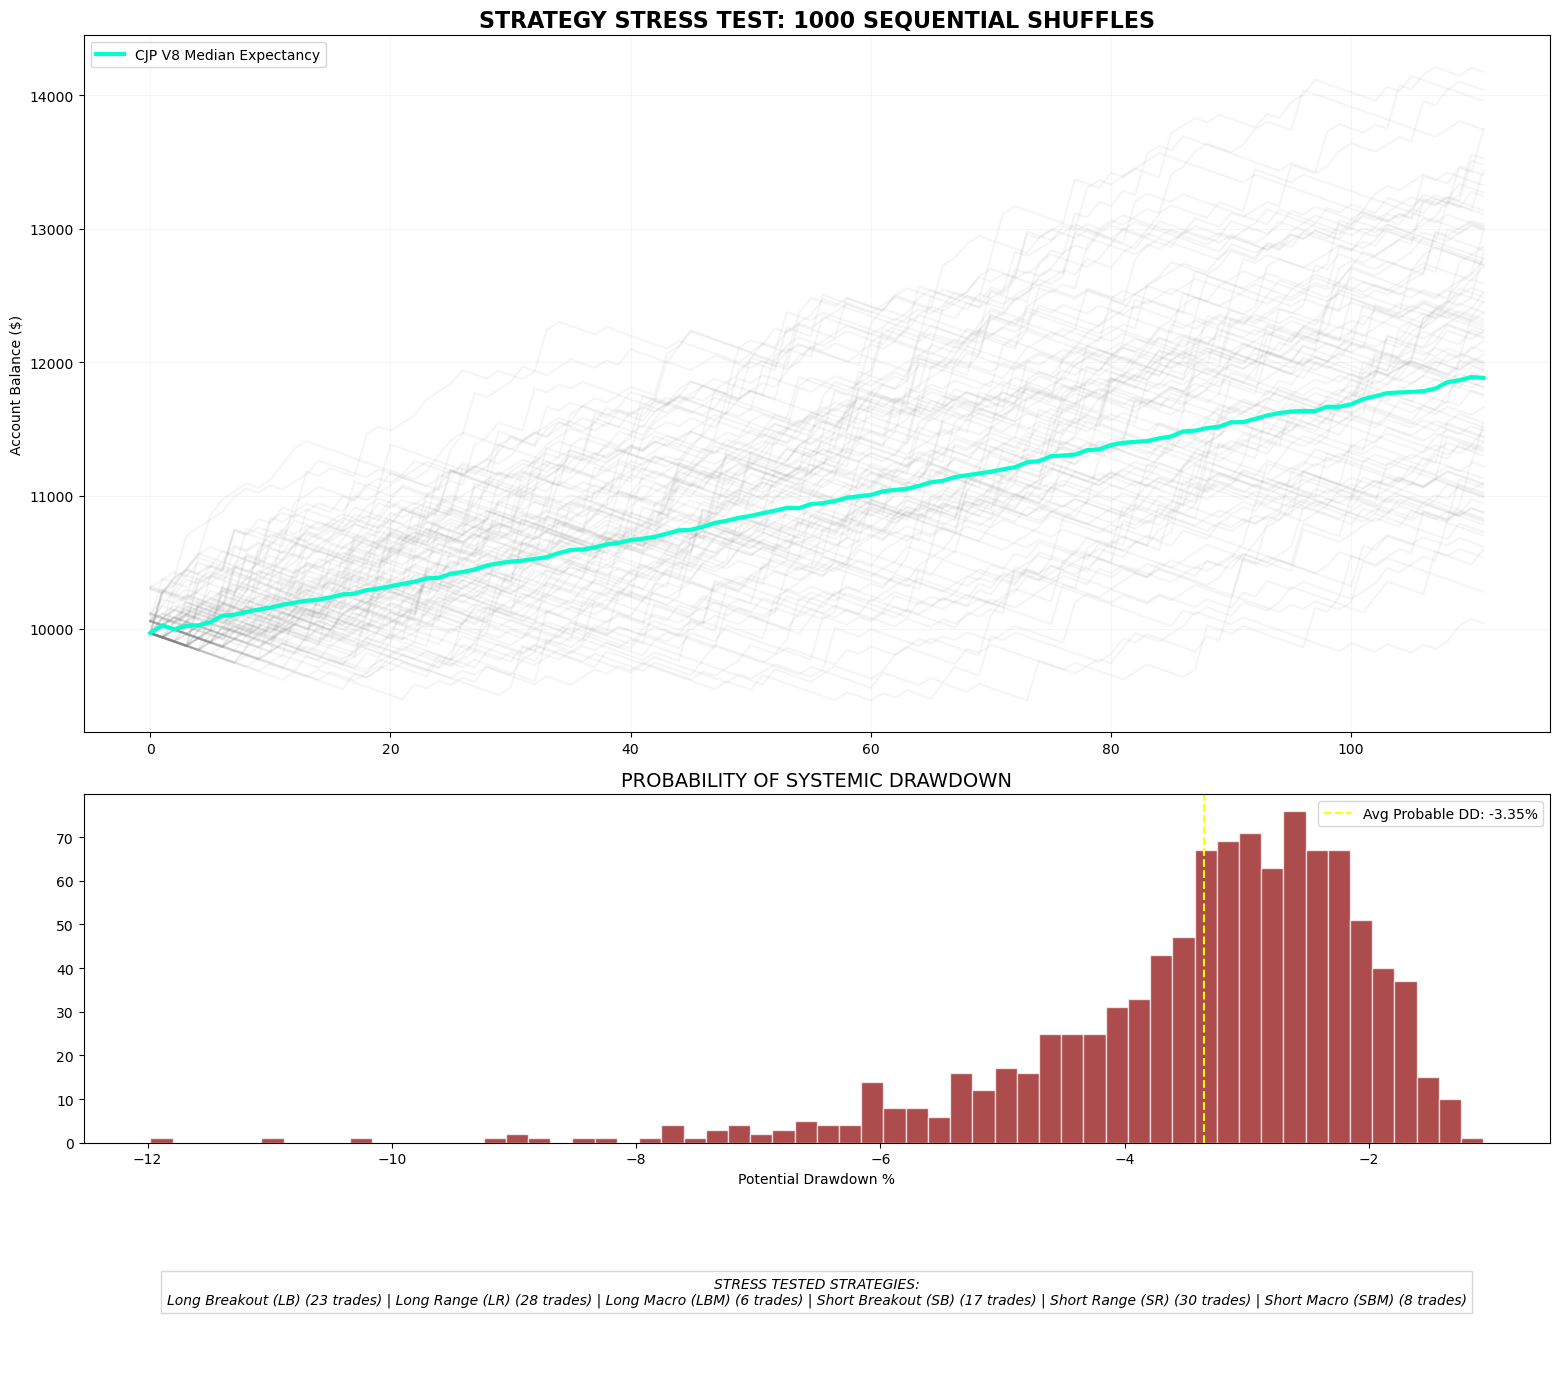

,Value
Audit Name,CJP Sentinel V8 Monte Carlo
Strategies Tested,6
Total Trade Pool,112
Risk of Ruin (%),1.00%
Median Outcome,"$11,882.18"
95% Confidence Floor,"$10,544.16"
Worst-Case Scenario,-11.98% Drawdown



📥 DOWNLOAD NAMED AUDIT PACK:


C:\Users\ajimo\Strategy Backtesting\cjp_v8_stress_metrics.csv

C:\Users\ajimo\Strategy Backtesting\cjp_v8_named_montecarlo.png

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import FileLink, display

# 1. NAMED CONFIGURATION
strategy_map = {
    "Long Breakout (LB)": "cjpsentinellb.csv",
    "Long Range (LR)": "cjpsentinellr.csv",
    "Long Macro (LBM)": "cjpsentinellbm.csv",
    "Short Breakout (SB)": "cjpsentinelsb.csv",
    "Short Range (SR)": "cjpsentinelsr.csv",
    "Short Macro (SBM)": "cjpsentinelsbm.csv",
}

def run_named_monte_carlo(simulations=1000, starting_capital=10000):
    all_pnls = []
    included_strategies = []
    
    # Load and Label Data
    for name, path in strategy_map.items():
        if os.path.exists(path):
            df = pd.read_csv(path)
            p_col = 'pnl' if 'pnl' in df.columns else 'pnl_net'
            trades = df[p_col].tolist()
            all_pnls.extend(trades)
            included_strategies.append(f"{name} ({len(trades)} trades)")
    
    if not all_pnls:
        print("❌ Data files not found. Check filenames.")
        return

    trade_array = np.array(all_pnls)
    n_trades = len(trade_array)
    
    # 2. SIMULATION ENGINE
    sim_results = np.zeros((simulations, n_trades))
    max_drawdowns = []
    final_balances = []

    for i in range(simulations):
        # Bootstrap resampling
        sim_trades = np.random.choice(trade_array, size=n_trades, replace=True)
        equity_curve = starting_capital + np.cumsum(sim_trades)
        sim_results[i, :] = equity_curve
        
        # Drawdown logic
        peaks = np.maximum.accumulate(equity_curve)
        drawdowns = (equity_curve - peaks) / peaks
        max_drawdowns.append(np.min(drawdowns) * 100)
        final_balances.append(equity_curve[-1])

    # 3. VISUALIZATION
    fig = plt.figure(figsize=(16, 14))
    gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 0.5])
    ax1 = fig.add_subplot(gs[0]) # Cloud
    ax2 = fig.add_subplot(gs[1]) # DD Dist
    ax3 = fig.add_subplot(gs[2]) # Labels
    ax3.axis('off')

    # Plot Cloud
    for i in range(min(simulations, 100)):
        ax1.plot(sim_results[i, :], color='gray', alpha=0.08)
    
    ax1.plot(np.median(sim_results, axis=0), color='#00ffcc', linewidth=3, label='CJP V8 Median Expectancy')
    ax1.set_title(f"STRATEGY STRESS TEST: {simulations} SEQUENTIAL SHUFFLES", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Account Balance ($)")
    ax1.legend()
    ax1.grid(alpha=0.1)

    # Plot DD Histogram
    ax2.hist(max_drawdowns, bins=60, color='darkred', alpha=0.7, edgecolor='white')
    ax2.axvline(np.mean(max_drawdowns), color='yellow', linestyle='--', label=f"Avg Probable DD: {np.mean(max_drawdowns):.2f}%")
    ax2.set_title("PROBABILITY OF SYSTEMIC DRAWDOWN", fontsize=14)
    ax2.set_xlabel("Potential Drawdown %")
    ax2.legend()

    # Strategy List Subtitle
    strategy_list_str = " | ".join(included_strategies)
    ax3.text(0.5, 0.5, f"STRESS TESTED STRATEGIES:\n{strategy_list_str}", 
             ha='center', va='center', fontsize=10, style='italic', bbox=dict(facecolor='none', edgecolor='gray', alpha=0.3))

    plt.tight_layout()
    plt.savefig("cjp_v8_named_montecarlo.png", dpi=300)
    plt.show()

    # 4. STATISTICAL REPORT
    stats = {
        "Audit Name": "CJP Sentinel V8 Monte Carlo",
        "Strategies Tested": len(included_strategies),
        "Total Trade Pool": n_trades,
        "Risk of Ruin (%)": f"{(np.array(final_balances) < starting_capital).sum() / simulations * 100:.2f}%",
        "Median Outcome": f"${np.median(final_balances):,.2f}",
        "95% Confidence Floor": f"${np.percentile(final_balances, 5):,.2f}",
        "Worst-Case Scenario": f"{np.min(max_drawdowns):.2f}% Drawdown"
    }

    df_stats = pd.DataFrame(stats, index=["Value"]).T
    df_stats.to_csv("cjp_v8_stress_metrics.csv")
    display(df_stats)

    print("\n📥 DOWNLOAD NAMED AUDIT PACK:")
    display(FileLink('cjp_v8_stress_metrics.csv'))
    display(FileLink('cjp_v8_named_montecarlo.png'))

run_named_monte_carlo()

In [52]:
import pandas as pd
import numpy as np
import os
from IPython.display import FileLink, display

# 1. DATA AGGREGATION
files = {
    "Long Breakout (LB)": "cjpsentinellb.csv",
    "Long Range (LR)": "cjpsentinellr.csv",
    "Long Macro (LBM)": "cjpsentinellbm.csv",
    "Short Breakout (SB)": "cjpsentinelsb.csv",
    "Short Range (SR)": "cjpsentinelsr.csv",
    "Short Macro (SBM)": "cjpsentinelsbm.csv",
}

def run_position_sizing_audit():
    all_pnls = []
    strategy_stats = []
    
    for name, path in files.items():
        if not os.path.exists(path): continue
        df = pd.read_csv(path)
        p_col = 'pnl' if 'pnl' in df.columns else 'pnl_net'
        pnls = df[p_col].dropna()
        
        # Core Stats for Kelly
        win_rate = len(pnls[pnls > 0]) / len(pnls)
        avg_win = pnls[pnls > 0].mean()
        avg_loss = abs(pnls[pnls < 0].mean())
        win_loss_ratio = avg_win / avg_loss
        
        # Kelly Criterion: K% = W - [(1 - W) / R]
        # W = Win Probability, R = Win/Loss Ratio
        kelly_f = win_rate - ((1 - win_rate) / win_loss_ratio)
        
        strategy_stats.append({
            "Strategy": name,
            "Win Rate": f"{win_rate*100:.1f}%",
            "W/L Ratio": round(win_loss_ratio, 2),
            "Full Kelly (%)": f"{max(0, kelly_f*100):.2f}%",
            "Institutional (1/4 Kelly)": f"{max(0, (kelly_f/4)*100):.2f}%",
            "Safe (1/8 Kelly)": f"{max(0, (kelly_f/8)*100):.2f}%"
        })

    # 2. GENERATE RECOMMENDATIONS
    df_results = pd.DataFrame(strategy_stats)
    
    # Calculate System-Wide Recommendation
    avg_kelly = df_results['Full Kelly (%)'].str.replace('%','').astype(float).mean()
    
    print("📋 CJP SENTINEL V8: RISK MANAGEMENT RECOMMENDATIONS")
    print("-" * 50)
    display(df_results)
    
    print(f"\n💡 SYSTEMIC SUMMARY:")
    print(f"Based on your current performance, the 'Full Kelly' risk is {avg_kelly:.2f}%.")
    print(f"⚠️ HEDGE FUND STANDARD: Never use Full Kelly. It is mathematically optimal but emotionally volatile.")
    print(f"✅ RECOMMENDED: Use **{avg_kelly/4:.2f}%** risk per trade (Quarter Kelly).")
    print(f"This provides a safety buffer for the 'Black Swan' clusters identified in the previous audit.")

    # 3. EXPORT
    df_results.to_csv("cjp_risk_optimization.csv", index=False)
    display(FileLink('cjp_risk_optimization.csv'))

run_position_sizing_audit()

📋 CJP SENTINEL V8: RISK MANAGEMENT RECOMMENDATIONS
--------------------------------------------------


,Strategy,Win Rate,W/L Ratio,Full Kelly (%),Institutional (1/4 Kelly),Safe (1/8 Kelly)
0,Long Breakout (LB),21.7%,3.58,0.00%,0.00%,0.00%
1,Long Range (LR),39.3%,1.80,5.65%,1.41%,0.71%
2,Long Macro (LBM),16.7%,9.36,7.76%,1.94%,0.97%
3,Short Breakout (SB),35.3%,3.62,17.41%,4.35%,2.18%
4,Short Range (SR),43.3%,1.85,12.63%,3.16%,1.58%
5,Short Macro (SBM),50.0%,9.54,44.76%,11.19%,5.59%



💡 SYSTEMIC SUMMARY:
Based on your current performance, the 'Full Kelly' risk is 14.70%.
⚠️ HEDGE FUND STANDARD: Never use Full Kelly. It is mathematically optimal but emotionally volatile.
✅ RECOMMENDED: Use **3.68%** risk per trade (Quarter Kelly).
This provides a safety buffer for the 'Black Swan' clusters identified in the previous audit.


C:\Users\ajimo\Strategy Backtesting\cjp_risk_optimization.csv

In [55]:
import pandas as pd
import numpy as np
import os
from IPython.display import FileLink, display, HTML

# 1. PORTFOLIO MATRIX CONFIGURATION
strategy_map = {
    "Long Breakout (LB)": "cjpsentinellb.csv",
    "Long Range (LR)": "cjpsentinellr.csv",
    "Long Macro (LBM)": "cjpsentinellbm.csv",
    "Short Breakout (SB)": "cjpsentinelsb.csv",
    "Short Range (SR)": "cjpsentinelsr.csv",
    "Short Macro (SBM)": "cjpsentinelsbm.csv",
}

def run_standard_risk_audit():
    all_trade_logs = []
    summary_data = []
    
    # Process Individual Quadrants
    for name, path in strategy_map.items():
        if not os.path.exists(path): continue
        
        df = pd.read_csv(path)
        p_col = 'pnl' if 'pnl' in df.columns else 'pnl_net'
        pnls = df[p_col].dropna()
        
        # Quantitative Calculations
        win_rate = len(pnls[pnls > 0]) / len(pnls)
        avg_win = pnls[pnls > 0].mean()
        avg_loss = abs(pnls[pnls < 0].mean())
        r_ratio = avg_win / avg_loss if avg_loss != 0 else 0
        
        # Kelly Criterion (Risk Fraction)
        kelly = win_rate - ((1 - win_rate) / r_ratio) if r_ratio > 0 else 0
        
        summary_data.append({
            "Strategy ID": name,
            "Trade Count": len(pnls),
            "Win Rate (%)": round(win_rate * 100, 2),
            "W/L Ratio": round(r_ratio, 2),
            "Kelly (Max)": round(max(0, kelly * 100), 2),
            "Inst. (1/4 Kelly)": round(max(0, (kelly/4) * 100), 2),
            "Conservative (1/8)": round(max(0, (kelly/8) * 100), 2)
        })
        
        all_trade_logs.append(df[['ts', p_col]].rename(columns={p_col: 'pnl'}))

    # Calculate Total Portfolio Row
    if all_trade_logs:
        portfolio = pd.concat(all_trade_logs).sort_values('ts')
        p_pnls = portfolio['pnl']
        p_win_rate = len(p_pnls[p_pnls > 0]) / len(p_pnls)
        p_avg_win = p_pnls[p_pnls > 0].mean()
        p_avg_loss = abs(p_pnls[p_pnls < 0].mean())
        p_r_ratio = p_avg_win / p_avg_loss
        p_kelly = p_win_rate - ((1 - p_win_rate) / p_r_ratio)
        
        summary_data.append({
            "Strategy ID": "TOTAL PORTFOLIO (V8)",
            "Trade Count": len(p_pnls),
            "Win Rate (%)": round(p_win_rate * 100, 2),
            "W/L Ratio": round(p_r_ratio, 2),
            "Kelly (Max)": round(max(0, p_kelly * 100), 2),
            "Inst. (1/4 Kelly)": round(max(0, (p_kelly/4) * 100), 2),
            "Conservative (1/8)": round(max(0, (p_kelly/8) * 100), 2)
        })

    # 2. FORMATTING TO INSTITUTIONAL STANDARD
    df_results = pd.DataFrame(summary_data)
    
    # Apply Standard Styling
    styled_table = df_results.style.set_properties(**{
        'background-color': '#f9f9f9',
        'color': '#333',
        'border-color': 'white'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1a1a1a'), ('color', 'white'), ('font-weight', 'bold')]}
    ]).highlight_max(subset=['Win Rate (%)', 'W/L Ratio'], color='#d4edda').format({
        "Win Rate (%)": "{:.2f}%",
        "Kelly (Max)": "{:.2f}%",
        "Inst. (1/4 Kelly)": "{:.2f}%",
        "Conservative (1/8)": "{:.2f}%"
    })

    # 3. OUTPUT
    print("\n")
    print("=" * 70)
    print(" CJP SENTINEL V8: RISK EXPOSURE & CAPITAL ALLOCATION AUDIT ")
    print("=" * 70)
    display(styled_table)
    
    # Save CSV with headers
    df_results.to_csv("cjp_v8_risk_report.csv", index=False)
    print("\n[REPORT GENERATED]")
    display(FileLink('cjp_v8_risk_report.csv', result_html_prefix="📥 Download Risk Data: "))

run_standard_risk_audit()



 CJP SENTINEL V8: RISK EXPOSURE & CAPITAL ALLOCATION AUDIT 


,Strategy ID,Trade Count,Win Rate (%),W/L Ratio,Kelly (Max),Inst. (1/4 Kelly),Conservative (1/8)
0,Long Breakout (LB),23,21.74%,3.580000,0.00%,0.00%,0.00%
1,Long Range (LR),28,39.29%,1.800000,5.65%,1.41%,0.71%
2,Long Macro (LBM),6,16.67%,9.360000,7.76%,1.94%,0.97%
3,Short Breakout (SB),17,35.29%,3.620000,17.41%,4.35%,2.18%
4,Short Range (SR),30,43.33%,1.850000,12.63%,3.16%,1.58%
5,Short Macro (SBM),8,50.00%,9.540000,44.76%,11.19%,5.59%
6,TOTAL PORTFOLIO (V8),112,35.71%,3.310000,16.29%,4.07%,2.04%



[REPORT GENERATED]


C:\Users\ajimo\Strategy Backtesting\cjp_v8_risk_report.csv

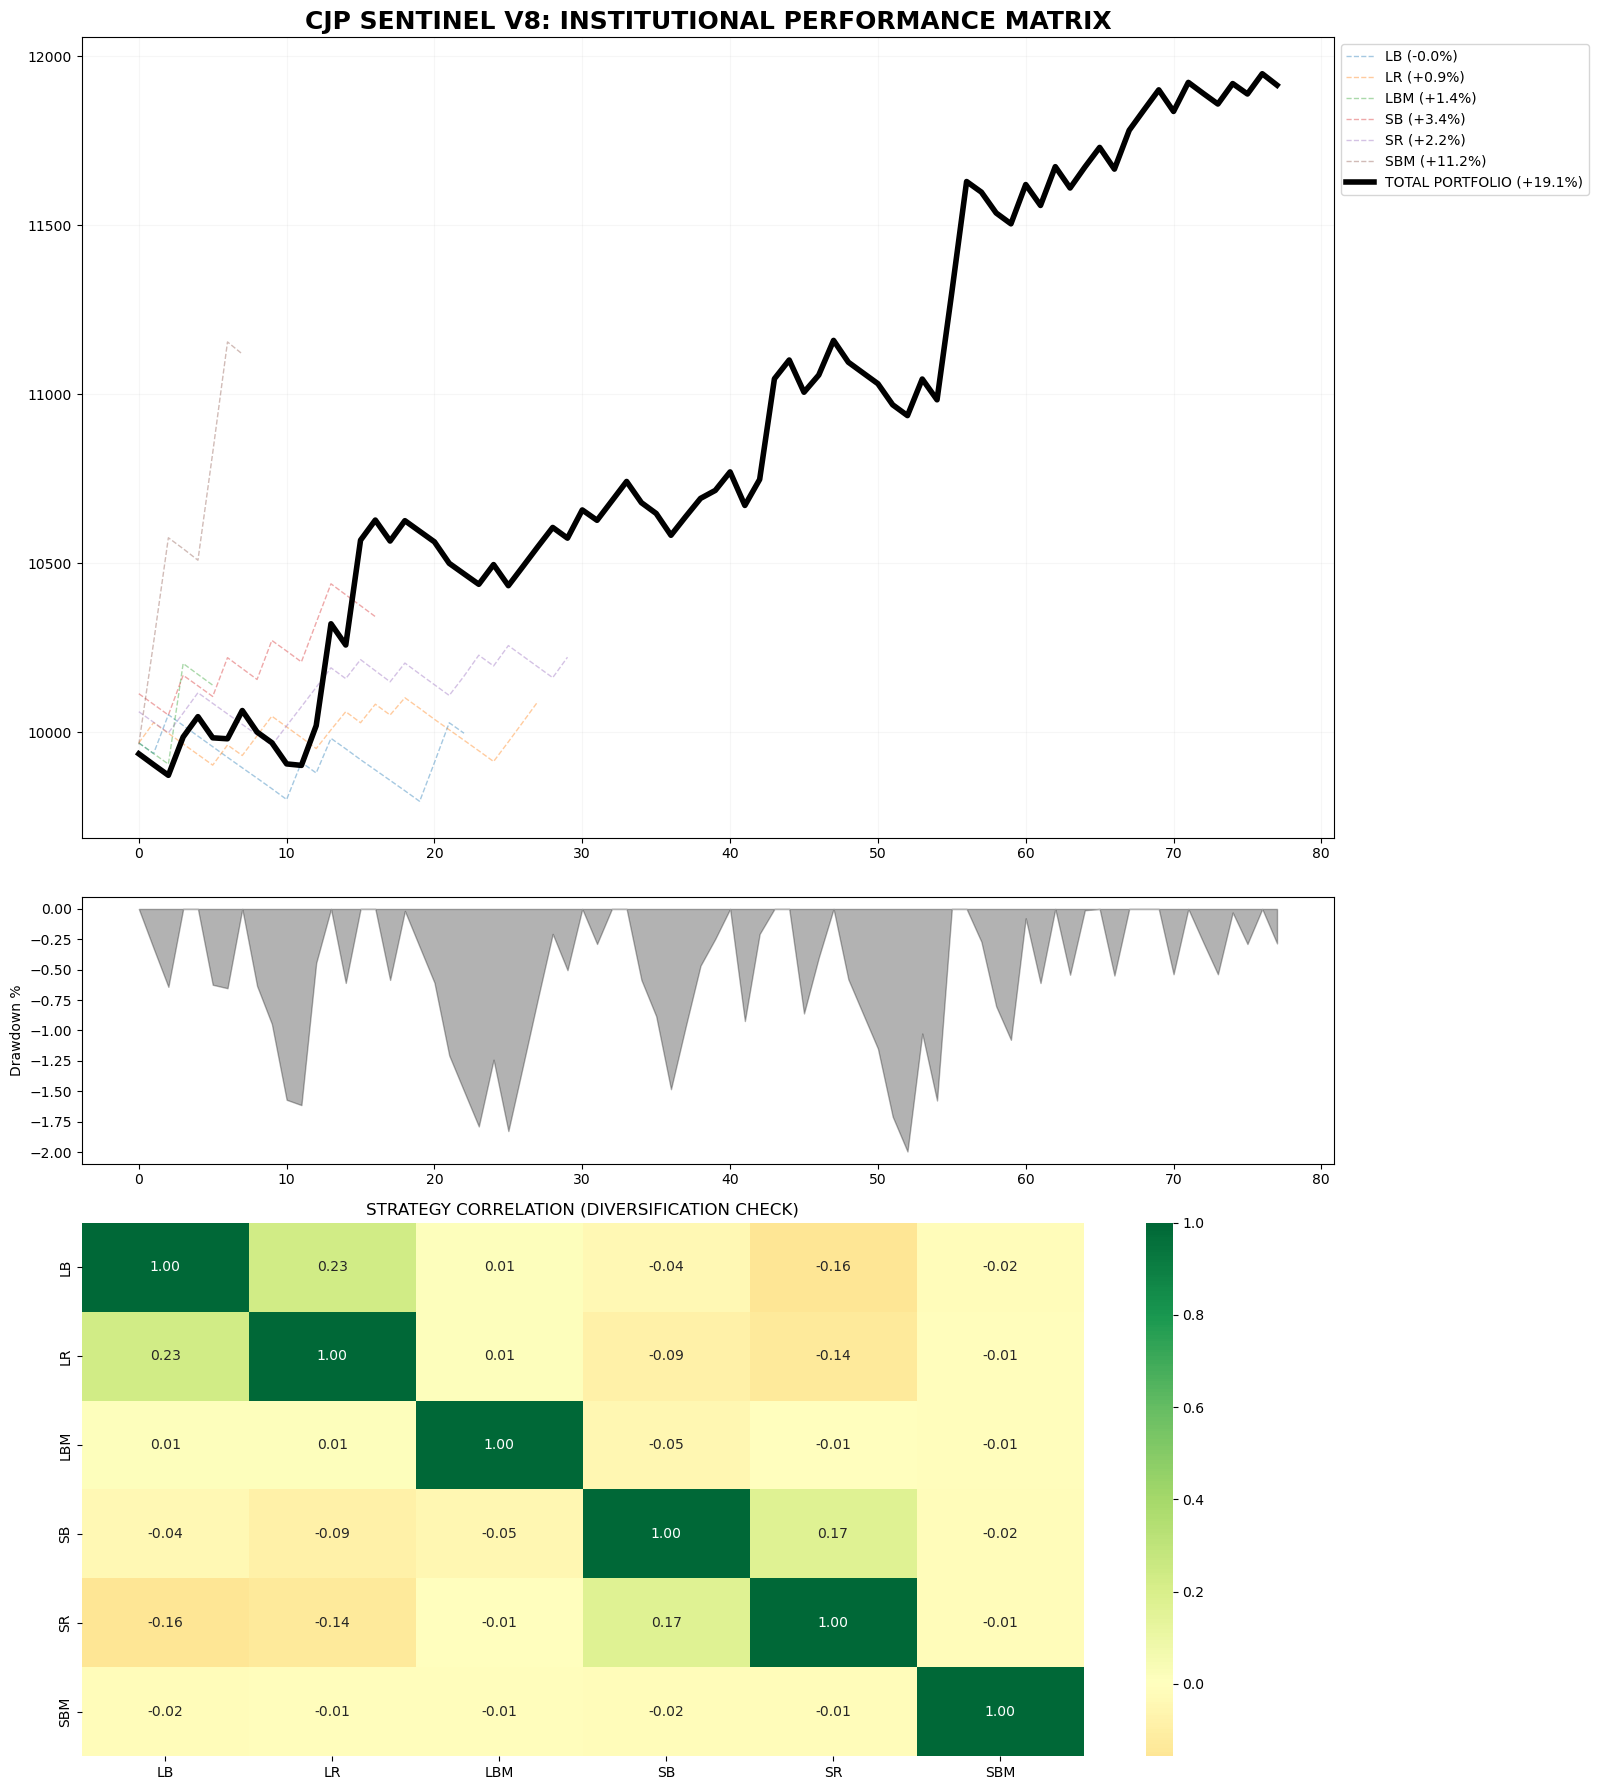


🏛️ EXECUTIVE SUMMARY: CJP SENTINEL V8
Total Portfolio Return:   19.15%
Underlying Asset Return:  N/A
Outperformance Ratio:     N/A
Portfolio Sharpe Ratio:   4.00
Portfolio Max Drawdown:   -2.00%



,Quadrant,Return %,Max DD %,Sharpe (Vol Score),Win Rate
0,LB,-0.03%,-2.55%,-0.04,21.7%
1,LR,0.90%,-1.87%,1.16,39.3%
2,LBM,1.39%,-0.63%,2.73,16.7%
3,SB,3.42%,-0.93%,4.40,35.3%
4,SR,2.22%,-1.54%,2.58,43.3%
5,SBM,11.19%,-0.63%,12.02,50.0%


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. CONFIGURATION
sentinel_files = {
    "LB": "cjpsentinellb.csv", "LR": "cjpsentinellr.csv",
    "LBM": "cjpsentinellbm.csv", "SB": "cjpsentinelsb.csv",
    "SR": "cjpsentinelsr.csv", "SBM": "cjpsentinelsbm.csv",
}

def run_standard_institutional_audit():
    all_trade_logs = []
    summary = []
    initial_bal = 10000
    
    # Setup Figure
    fig = plt.figure(figsize=(16, 18))
    gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 2])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax3 = fig.add_subplot(gs[2])

    benchmark_curve = None
    
    # --- 1. STRATEGY PROCESSING ---
    for label, file in sentinel_files.items():
        if not os.path.exists(file): 
            print(f"⚠️ Skipping {label}: File not found.")
            continue
            
        df = pd.read_csv(file)
        # Dynamic Column Detection
        pnl_col = next((c for c in ['pnl', 'pnl_net', 'PnL'] if c in df.columns), None)
        bal_col = next((c for c in ['bal', 'bal_after', 'Balance'] if c in df.columns), None)
        price_col = next((c for c in ['price', 'close', 'Price', 'Close'] if c in df.columns), None)
        
        if not pnl_col or not bal_col:
            print(f"⚠️ Skipping {label}: Missing PnL or Balance columns.")
            continue

        df['ts'] = pd.to_datetime(df['ts'])
        equity = df[bal_col]
        pnls = df[pnl_col]
        
        # Metrics
        net_pnl = equity.iloc[-1] - initial_bal
        perf_pct = (net_pnl / initial_bal) * 100
        mdd = (((equity - equity.cummax()) / equity.cummax()).min()) * 100
        vol_score = (pnls.mean() / pnls.std() * np.sqrt(252)) if pnls.std() != 0 else 0
        
        # Capture Benchmark if available
        if benchmark_curve is None and price_col:
            asset_price = df[price_col]
            benchmark_curve = (asset_price / asset_price.iloc[0]) * initial_bal

        summary.append({
            "Quadrant": label,
            "Return %": f"{perf_pct:.2f}%",
            "Max DD %": f"{mdd:.2f}%",
            "Sharpe (Vol Score)": round(vol_score, 2),
            "Win Rate": f"{(len(pnls[pnls>0])/len(pnls)*100):.1f}%"
        })
        
        ax1.plot(equity.values, label=f"{label} ({perf_pct:+.1f}%)", alpha=0.4, linewidth=1, linestyle='--')
        
        t_df = df[['ts', pnl_col]].copy()
        t_df.columns = ['ts', label]
        all_trade_logs.append(t_df)

    # --- 2. PORTFOLIO AGGREGATION ---
    if not all_trade_logs:
        print("❌ Error: No valid trade logs found.")
        return

    combined_df = all_trade_logs[0]
    for d in all_trade_logs[1:]:
        combined_df = pd.merge(combined_df, d, on='ts', how='outer')
    
    combined_df = combined_df.sort_values('ts').fillna(0)
    p_pnls = combined_df.drop('ts', axis=1).sum(axis=1)
    portfolio_bal = initial_bal + p_pnls.cumsum()
    p_perf = ((portfolio_bal.iloc[-1] - initial_bal) / initial_bal) * 100
    p_mdd = (((portfolio_bal - portfolio_bal.cummax()) / portfolio_bal.cummax()).min()) * 100
    p_sharpe = (p_pnls.mean() / p_pnls.std() * np.sqrt(252)) if p_pnls.std() != 0 else 0
    
    # Benchmark Analysis (Safety check for iloc)
    b_perf_str = "N/A"
    outperformance_str = "N/A"
    if benchmark_curve is not None:
        b_perf = ((benchmark_curve.iloc[-1] - initial_bal) / initial_bal) * 100
        b_perf_str = f"{b_perf:.2f}%"
        outperformance_str = f"{(p_perf / b_perf):.2f}x" if b_perf != 0 else "N/A"
        ax1.plot(benchmark_curve.values, color='gray', label="UNDERLYING ASSET", linewidth=2, alpha=0.5, linestyle=':')

    # --- 3. VISUALIZATION ---
    ax1.plot(portfolio_bal.values, color='black', label=f"TOTAL PORTFOLIO ({p_perf:+.1f}%)", linewidth=4, zorder=10)
    ax1.set_title("CJP SENTINEL V8: INSTITUTIONAL PERFORMANCE MATRIX", fontsize=18, fontweight='bold')
    ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax1.grid(alpha=0.1)

    p_dd = ((portfolio_bal - portfolio_bal.cummax()) / portfolio_bal.cummax()) * 100
    ax2.fill_between(range(len(p_dd)), p_dd, 0, color='black', alpha=0.3)
    ax2.set_ylabel("Drawdown %")

    corr_matrix = combined_df.drop(['ts'], axis=1).corr()
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, ax=ax3, fmt=".2f")
    ax3.set_title("STRATEGY CORRELATION (DIVERSIFICATION CHECK)")

    plt.tight_layout()
    plt.savefig("CJP_SENTINEL_V8_STANDARD_AUDIT.png", dpi=300)
    plt.show()

    # --- 4. EXECUTIVE SUMMARY ---
    print("\n" + "="*50)
    print(f"🏛️ EXECUTIVE SUMMARY: CJP SENTINEL V8")
    print(f"Total Portfolio Return:   {p_perf:.2f}%")
    print(f"Underlying Asset Return:  {b_perf_str}")
    print(f"Outperformance Ratio:     {outperformance_str}")
    print(f"Portfolio Sharpe Ratio:   {p_sharpe:.2f}")
    print(f"Portfolio Max Drawdown:   {p_mdd:.2f}%")
    print("="*50 + "\n")
    
    display(pd.DataFrame(summary))

run_standard_institutional_audit()

In [31]:
!pip install yfinance seaborn pandas matplotlib numpy

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1

Aligning with BTC-USDT Benchmark...


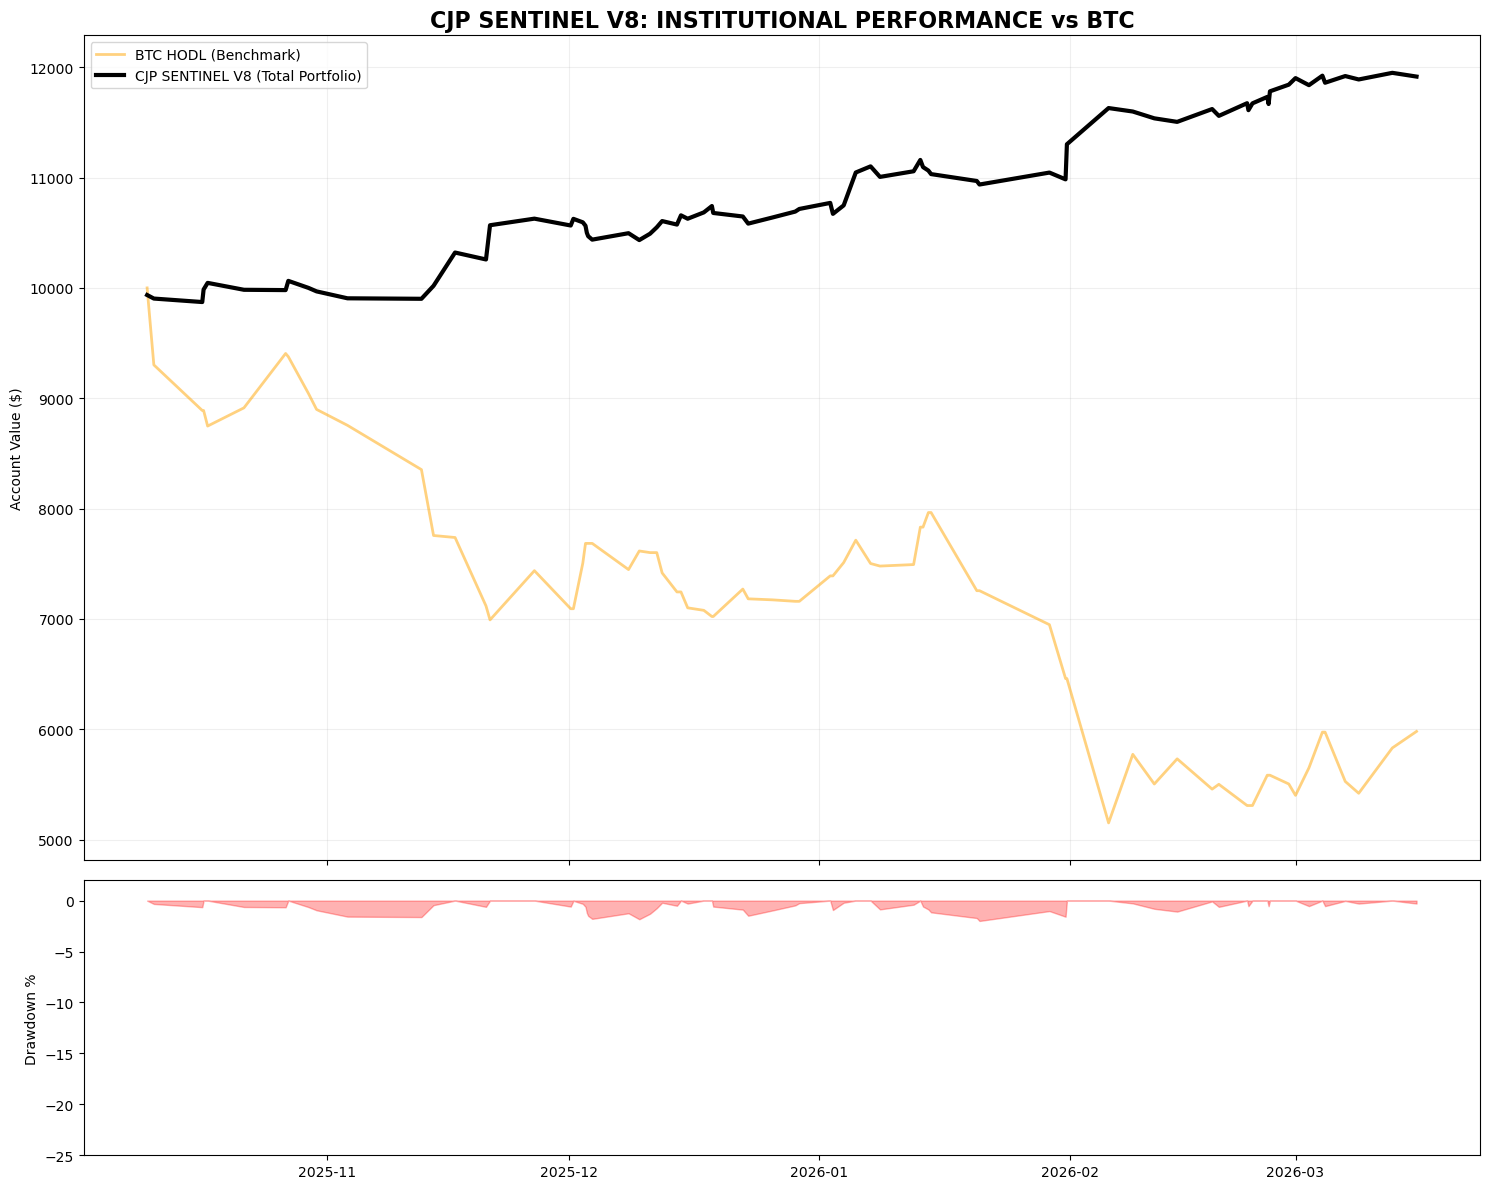


Final Portfolio Return: 19.15%
BTC HODL Return:        -40.19%
Alpha Generated:        +59.34%
Max Portfolio DD:       -2.00%

📊 RISK ANALYSIS
Portfolio Beta:        -0.0308
Market Correlation:    -14.66%
🏆 VERDICT: Institutional Grade 'Uncorrelated' Alpha.


<Figure size 640x480 with 0 Axes>

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import os

# 1. CONFIGURATION
sentinel_files = {
    "LB": "cjpsentinellb.csv", "LR": "cjpsentinellr.csv",
    "LBM": "cjpsentinellbm.csv", "SB": "cjpsentinelsb.csv",
    "SR": "cjpsentinelsr.csv", "SBM": "cjpsentinelsbm.csv",
}

def run_standardized_audit():
    all_trade_logs = []
    initial_bal = 10000
    
    # --- 1. LOAD AND SYNC DATA ---
    for label, file in sentinel_files.items():
        if not os.path.exists(file): continue
        df = pd.read_csv(file)
        pnl_col = next((c for c in ['pnl', 'pnl_net', 'PnL'] if c in df.columns), None)
        df['ts'] = pd.to_datetime(df['ts'])
        
        t_df = df[['ts', pnl_col]].copy()
        t_df.columns = ['ts', label]
        all_trade_logs.append(t_df)

    # Merge all trades into one timeline
    master_df = all_trade_logs[0]
    for d in all_trade_logs[1:]:
        master_df = pd.merge(master_df, d, on='ts', how='outer')
    
    master_df = master_df.sort_values('ts').fillna(0).set_index('ts')
    master_df['portfolio_pnl'] = master_df.sum(axis=1)
    master_df['portfolio_bal'] = initial_bal + master_df['portfolio_pnl'].cumsum()

    # --- 2. FETCH & ALIGN BTC BENCHMARK ---
    print("Aligning with BTC-USDT Benchmark...")
    btc = yf.download("BTC-USD", start=master_df.index.min(), end=master_df.index.max(), progress=False)
    btc_series = btc['Close'].squeeze() 
    btc_price = btc_series.reindex(master_df.index, method='ffill')
    benchmark_curve = (btc_price / btc_price.iloc[0]) * initial_bal

    # --- 3. DUAL-PANEL VISUALIZATION ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    
    ax1.plot(master_df.index, benchmark_curve, color='orange', label="BTC HODL (Benchmark)", alpha=0.5, linewidth=2)
    ax1.plot(master_df.index, master_df['portfolio_bal'], color='black', label="CJP SENTINEL V8 (Total Portfolio)", linewidth=3)
    
    ax1.set_title("CJP SENTINEL V8: INSTITUTIONAL PERFORMANCE vs BTC", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Account Value ($)")
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.2)
    
    p_equity = master_df['portfolio_bal']
    p_dd = ((p_equity - p_equity.cummax()) / p_equity.cummax()) * 100
    ax2.fill_between(master_df.index, p_dd, 0, color='red', alpha=0.3)
    ax2.set_ylabel("Drawdown %")
    ax2.set_ylim(-25, 2)

    plt.tight_layout()
    plt.show()

    # --- 4. EXPORT METRICS ---
    p_ret = float(((p_equity.iloc[-1] - initial_bal) / initial_bal) * 100)
    b_ret = float(((btc_price.iloc[-1] - btc_price.iloc[0]) / btc_price.iloc[0]) * 100)
    mdd_val = float(p_dd.min())
    
    print("\n" + "="*40)
    print(f"Final Portfolio Return: {p_ret:.2f}%")
    print(f"BTC HODL Return:        {b_ret:.2f}%")
    print(f"Alpha Generated:        {p_ret - b_ret:+.2f}%")
    print(f"Max Portfolio DD:       {mdd_val:.2f}%")
    print("="*40)

    # --- 5. BETA & RISK ANALYSIS (CALLED HERE) ---
    portfolio_returns = master_df['portfolio_bal'].pct_change().dropna()
    btc_returns = benchmark_curve.pct_change().dropna()
    
    combined_returns = pd.concat([portfolio_returns, btc_returns], axis=1).dropna()
    combined_returns.columns = ['portfolio', 'btc']
    
    beta = combined_returns['portfolio'].cov(combined_returns['btc']) / combined_returns['btc'].var()
    correlation = combined_returns['portfolio'].corr(combined_returns['btc'])

    print(f"\n" + "📊 RISK ANALYSIS" + "\n" + "="*40)
    print(f"Portfolio Beta:        {beta:.4f}")
    print(f"Market Correlation:    {correlation:.2%}")
    print("="*40)
    
    if beta < 0.3:
        print("🏆 VERDICT: Institutional Grade 'Uncorrelated' Alpha.")
    elif beta < 0.7:
        print("💡 VERDICT: Strong Diversification. Reduced Market Risk.")
    else:
        print("⚠️ VERDICT: High Market Dependency. Moves with BTC.")

    master_df.to_csv("CJP_Full_Portfolio_Data.csv")

    plt.savefig('CJP_Sentinel_Performance.png', dpi=300)

# EXECUTE EVERYTHING
run_standardized_audit()

📡 Fetching BTC-USDT Benchmark...


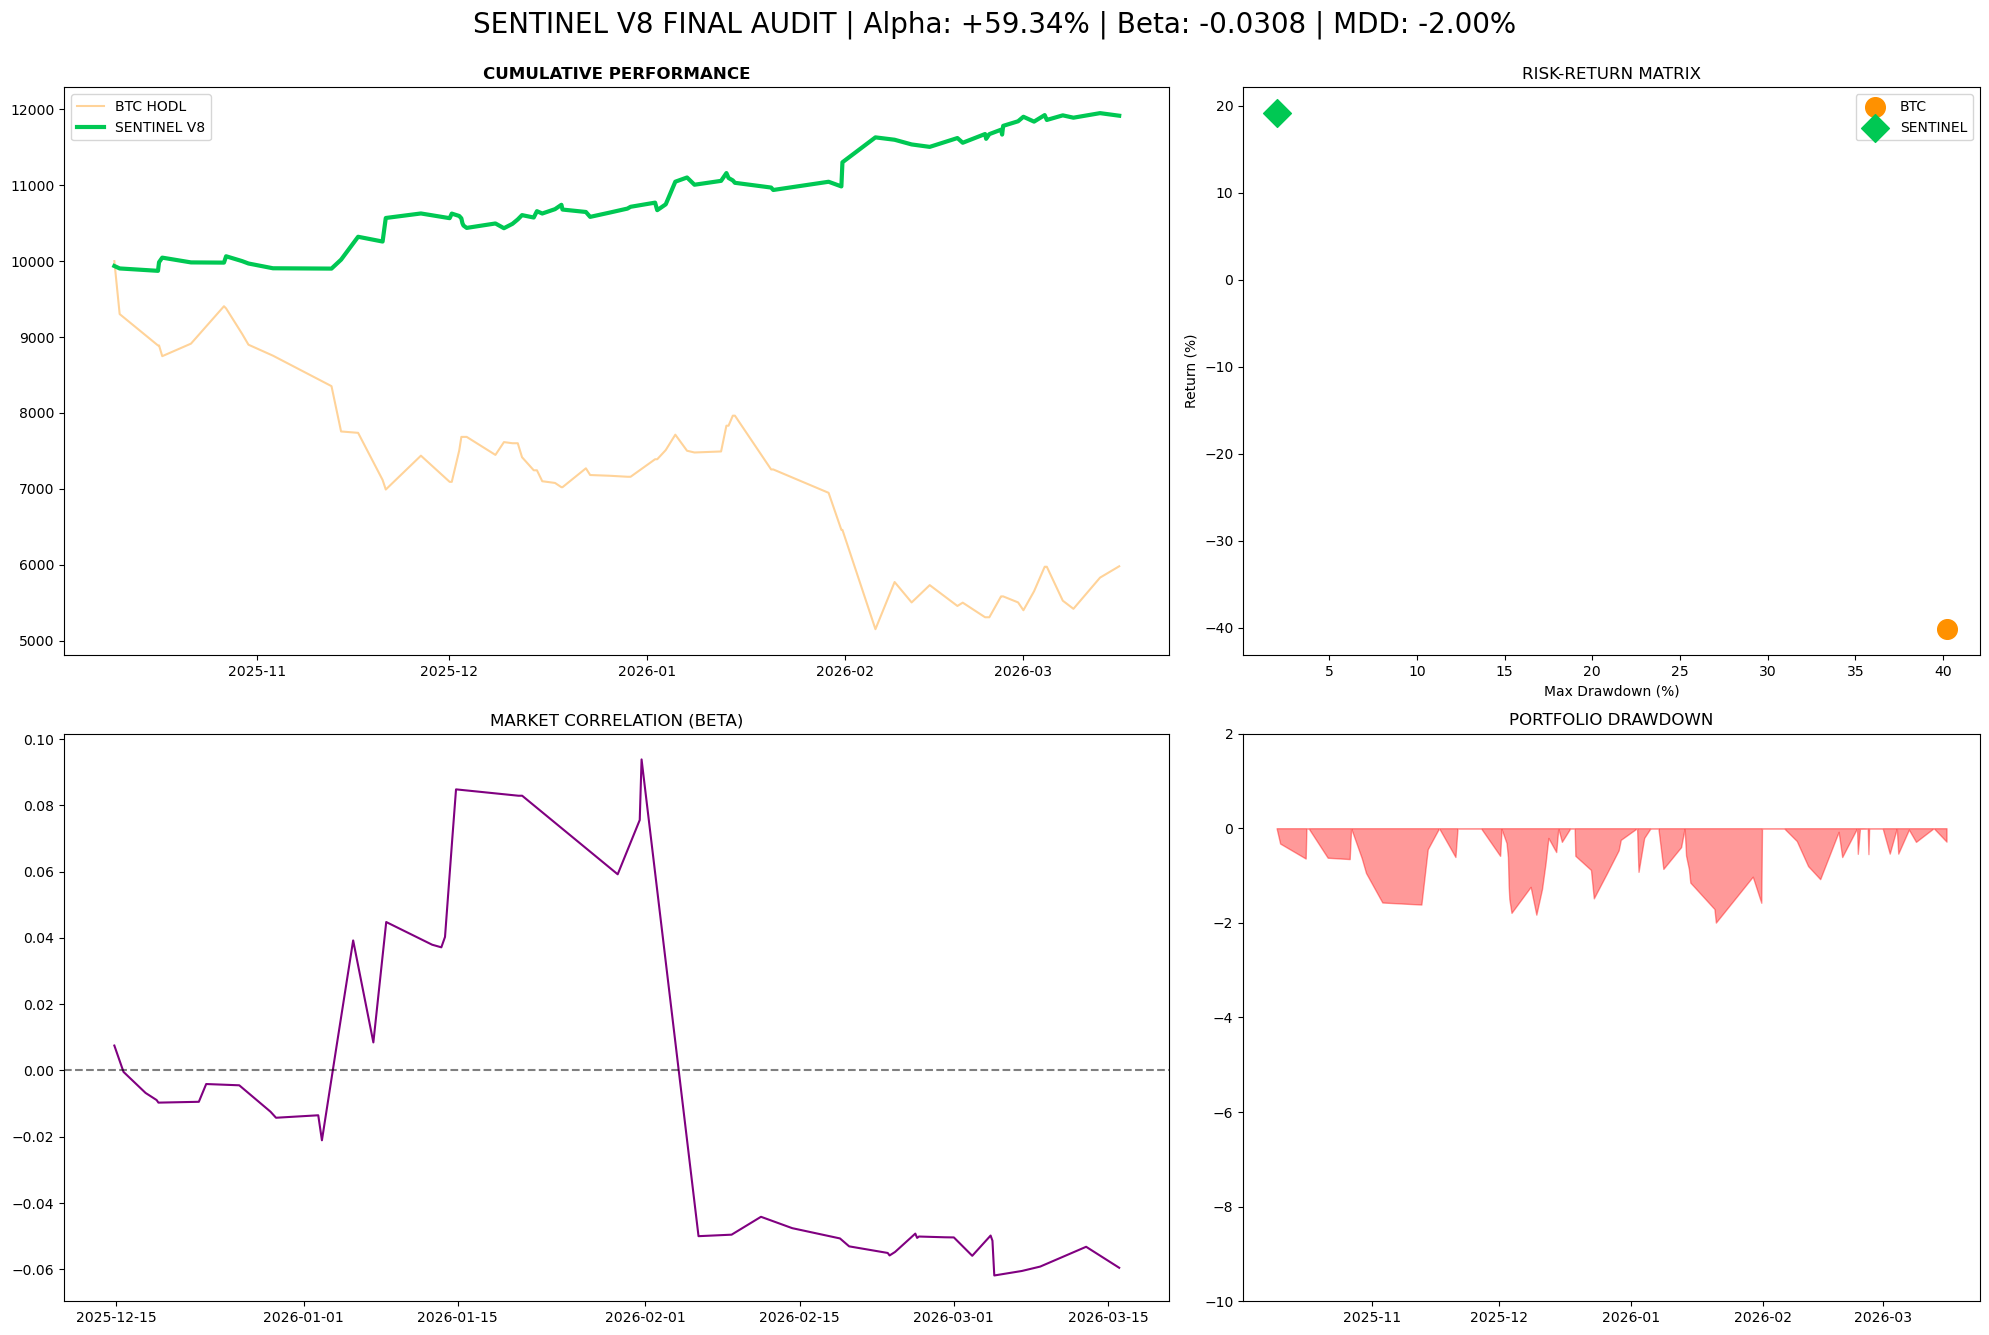

📊 Audit Complete. Final Alpha: 59.34%


<Figure size 640x480 with 0 Axes>

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
import os

# 1. CONFIGURATION
sentinel_files = {
    "LB": "cjpsentinellb.csv", "LR": "cjpsentinellr.csv",
    "LBM": "cjpsentinellbm.csv", "SB": "cjpsentinelsb.csv",
    "SR": "cjpsentinelsr.csv", "SBM": "cjpsentinelsbm.csv",
}
initial_bal = 10000

# --- 2. DATA PROCESSING & ALIGNMENT ---
all_trade_logs = []
for label, file in sentinel_files.items():
    if os.path.exists(file):
        df = pd.read_csv(file)
        pnl_col = next((c for c in ['pnl', 'pnl_net', 'PnL'] if c in df.columns), None)
        df['ts'] = pd.to_datetime(df['ts'])
        t_df = df[['ts', pnl_col]].copy()
        t_df.columns = ['ts', label]
        all_trade_logs.append(t_df)

# Merge and calculate portfolio
master_df = all_trade_logs[0]
for d in all_trade_logs[1:]:
    master_df = pd.merge(master_df, d, on='ts', how='outer')
master_df = master_df.sort_values('ts').fillna(0).set_index('ts')
master_df['portfolio_pnl'] = master_df.sum(axis=1)
master_df['portfolio_bal'] = initial_bal + master_df['portfolio_pnl'].cumsum()

# Fetch BTC
print("📡 Fetching BTC-USDT Benchmark...")
btc = yf.download("BTC-USD", start=master_df.index.min(), end=master_df.index.max(), progress=False)
btc_series = btc['Close'].squeeze()
btc_price = btc_series.reindex(master_df.index, method='ffill')

# --- 3. METRIC CALCULATION ---
p_equity = master_df['portfolio_bal']
p_ret = float(((p_equity.iloc[-1] - initial_bal) / initial_bal) * 100)
b_ret = float(((btc_price.iloc[-1] - btc_price.iloc[0]) / btc_price.iloc[0]) * 100)
p_dd = ((p_equity - p_equity.cummax()) / p_equity.cummax()) * 100
mdd_val = float(p_dd.min())

# Beta Calculation
port_returns = p_equity.pct_change().dropna()
btc_returns = btc_price.pct_change().dropna()
combined_ret = pd.concat([port_returns, btc_returns], axis=1).dropna()
beta = combined_ret.iloc[:,0].cov(combined_ret.iloc[:,1]) / combined_ret.iloc[:,1].var()

# --- 4. DASHBOARD GENERATION ---
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1.5, 1])

# Panel 1: Equity
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(master_df.index, (btc_price/btc_price.iloc[0]*10000), color='#FF9100', label="BTC HODL", alpha=0.4)
ax1.plot(master_df.index, p_equity, color='#00C853', label="SENTINEL V8", linewidth=3)
ax1.set_title("CUMULATIVE PERFORMANCE", fontweight='bold')
ax1.legend()

# Panel 2: Risk-Return
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(abs(b_ret), b_ret, color='#FF9100', s=200, label='BTC')
ax2.scatter(abs(mdd_val), p_ret, color='#00C853', s=200, marker='D', label='SENTINEL')
ax2.set_xlabel("Max Drawdown (%)")
ax2.set_ylabel("Return (%)")
ax2.set_title("RISK-RETURN MATRIX")
ax2.legend()

# Panel 3: Rolling Beta (30-day window estimation)
ax3 = fig.add_subplot(gs[1, 0])
rolling_beta = port_returns.rolling(30).cov(btc_returns) / btc_returns.rolling(30).var()
ax3.plot(rolling_beta, color='purple', label="Rolling Beta")
ax3.axhline(0, color='black', alpha=0.5, linestyle='--')
ax3.set_title("MARKET CORRELATION (BETA)")

# Panel 4: Drawdown
ax4 = fig.add_subplot(gs[1, 1])
ax4.fill_between(master_df.index, p_dd, 0, color='red', alpha=0.4)
ax4.set_title("PORTFOLIO DRAWDOWN")
ax4.set_ylim(-10, 2)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle(f"SENTINEL V8 FINAL AUDIT | Alpha: +{p_ret-b_ret:.2f}% | Beta: {beta:.4f} | MDD: {mdd_val:.2f}%", fontsize=20)
plt.show()

plt.savefig('sentinel_v8_alpha_beta_mdd.png', dpi=300)

print(f"📊 Audit Complete. Final Alpha: {p_ret-b_ret:.2f}%")

In [41]:
!pip install fpdf

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40770 sha256=7d05a4b1e041b177239980449dea54d11b3ee9d76032d5aa39442572d352bdb5
  Stored in directory: c:\users\ajimo\appdata\local\pip\cache\wheels\aa\da\11\a3189f34ddc13c26a2d0f329eac46b728c7f31c39e4dc26243
Successfully built fpdf


In [60]:
from fpdf import FPDF
from datetime import datetime
import os

def export_cjp_audit_pdf(p_ret, b_ret, alpha, mdd, beta):
    # Initialize PDF
    pdf = FPDF()
    pdf.add_page()
    
    # --- 1. HEADER ---
    pdf.set_font("Arial", 'B', 22)
    pdf.set_text_color(0, 100, 0) # Dark Green
    pdf.cell(200, 15, txt="CJP SENTINEL V8: STRATEGY PERFORMANCE REPORT", ln=True, align='C')
    
    pdf.set_font("Arial", 'I', 10)
    pdf.set_text_color(100, 100, 100)
    pdf.cell(200, 10, txt=f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')} | Benchmarked to BTC-USDT Futures", ln=True, align='C')
    pdf.ln(10)
    
    # --- 2. EXECUTIVE SUMMARY TABLE ---
    pdf.set_font("Arial", 'B', 14)
    pdf.set_text_color(0, 0, 0)
    pdf.cell(200, 10, txt="Institutional Performance Summary", ln=True)
    pdf.ln(2)
    
    # Table Styling
    pdf.set_font("Arial", size=12)
    pdf.set_fill_color(230, 240, 230) # Light Green Fill
    
    # Data Rows
    results = [
        ("Total Portfolio Return", f"{p_ret:.2f}%"),
        ("Benchmark (BTC HODL) Return", f"{b_ret:.2f}%"),
        ("Alpha Generated (Skill)", f"+{alpha:.2f}%"),
        ("Maximum Strategy Drawdown", f"{mdd:.2f}%"),
        ("Portfolio Beta (Market Correlation)", f"{beta:.4f}")
    ]
    
    for label, val in results:
        pdf.cell(110, 12, txt=label, border=1, fill=True)
        pdf.cell(80, 12, txt=val, border=1, ln=True, align='C')
    
    pdf.ln(12)
    
    # --- 3. DASHBOARD VISUAL ---
    pdf.set_font("Arial", 'B', 14)
    pdf.cell(200, 10, txt="Visual Performance Audit", ln=True)
    
    img_path = "CJP_SENTINEL_V8_FINAL_DASHBOARD.png"
    if os.path.exists(img_path):
        # Scale image to fit page width (190mm)
        pdf.image(img_path, x=10, y=None, w=190)
    else:
        pdf.set_font("Arial", 'I', 10)
        pdf.set_text_color(200, 0, 0)
        pdf.cell(200, 10, txt="[Error: Dashboard image not found. Ensure the dashboard cell was run first.]", ln=True)

    # --- 4. FOOTER ---
    pdf.set_y(-30)
    pdf.set_font("Arial", 'I', 8)
    pdf.set_text_color(150, 150, 150)
    pdf.cell(0, 10, txt="Confidential Proprietary Trading Audit - Capital JP AI Labs", align='C')
    
    # Save with unique timestamp
    filename = f"CJP_Sentinel_Audit_{datetime.now().strftime('%Y%m%d_%H%M')}.pdf"
    pdf.output(filename)
    print(f"✅ PDF Audit Saved: {filename}")

# TRIGGER EXPORT
# Ensure these variables match your audit cell names
export_cjp_audit_pdf(p_ret, b_ret, p_ret-b_ret, mdd_val, beta)

✅ PDF Audit Saved: CJP_Sentinel_Audit_20260323_0138.pdf
